<a href="https://colab.research.google.com/github/pgianinh50364/nlp_course/blob/2024/week02_classification/homework_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Salary prediction, episode II: make it actually work (4 points)

Your main task is to use some of the tricks you've learned on the network and analyze if you can improve __validation MAE__. Try __at least 3 options__ from the list below for a passing grade. Write a short report about what you have tried. More ideas = more bonus points.

__Please be serious:__ " plot learning curves in MAE/epoch, compare models based on optimal performance, test one change at a time. You know the drill :)

You can use either __pytorch__ or __tensorflow__ or any other framework (e.g. pure __keras__). Feel free to adapt the seminar code for your needs. For tensorflow version, consider `seminar_tf2.ipynb` as a starting point.


In [ ]:
!pip install pytorch_lightning
!pip install kaggle
!pip install dython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.3/819.3 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.3/927.3 kB 45.7 MB/s eta 0:00:00


In [ ]:
!mkdir /.kaggle
!mv kaggle.json /.kaggle
!mv /.kaggle /root/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
import kagglehub
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dython.nominal import associations
from dython.nominal import identify_nominal_columns

import torch
from torch import nn
from torch.nn import functional as F
import pytorch_lightning as pl

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

import gc

In [ ]:
# Download latest version
path = kagglehub.dataset_download("rkiattisak/salaly-prediction-for-beginer")

# Replace 'Salary_Data.csv' with the actual file name if different.
file_path = os.path.join(path, 'Salary Data.csv')

data = pd.read_csv(file_path)
print("Path to dataset files:", file_path)

100%|██████████| 3.20k/3.20k [00:00<00:00, 1.76MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rkiattisak/salaly-prediction-for-beginer/versions/1/Salary Data.csv


In [ ]:
data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [ ]:
filtered_data = data.dropna(axis=0)

<Axes: xlabel='Salary', ylabel='Count'>

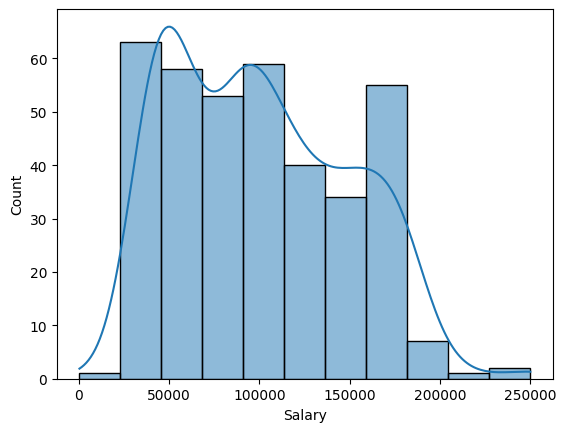

In [ ]:
sns.histplot(filtered_data['Salary'], kde=True)

In [ ]:
from IPython.core.display import HTML
def multi_table(table_list):
    ''' Acceps a list of IpyTable objects and returns a table which contains each IpyTable in a cell
    '''
    return HTML('<table><tr style="background-color:black;">'+
               ''.join(['<td>' + table._repr_html_() + '</td>' for table in table_list]) +
               '</tr></table>')

In [ ]:
cat_feats = filtered_data.select_dtypes(include='object').columns
num_feats = filtered_data.select_dtypes(exclude='object').columns
n_unique_df = {}
n_unique_df = {
    var:pd.DataFrame(filtered_data[var].value_counts())
    for var in filtered_data[cat_feats]
    }
multi_table([n_unique_df[col] for col in cat_feats])

,count
Gender,
Male,194
Female,179
,count
Education Level,
Bachelor's,224
Master's,98
PhD,51
,count
Job Title,


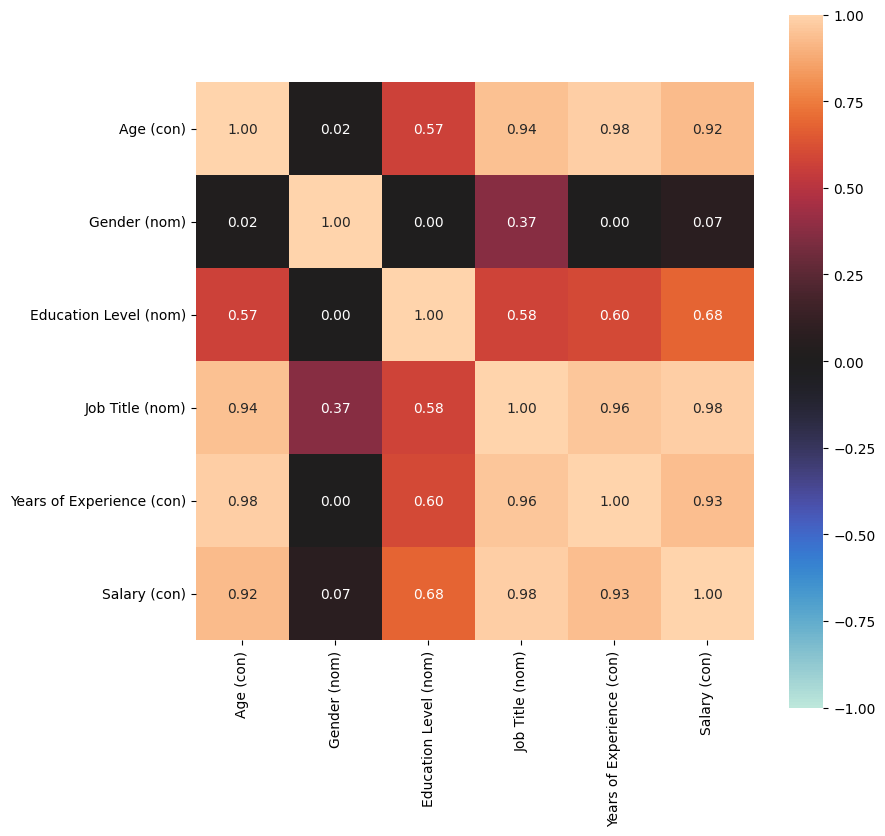

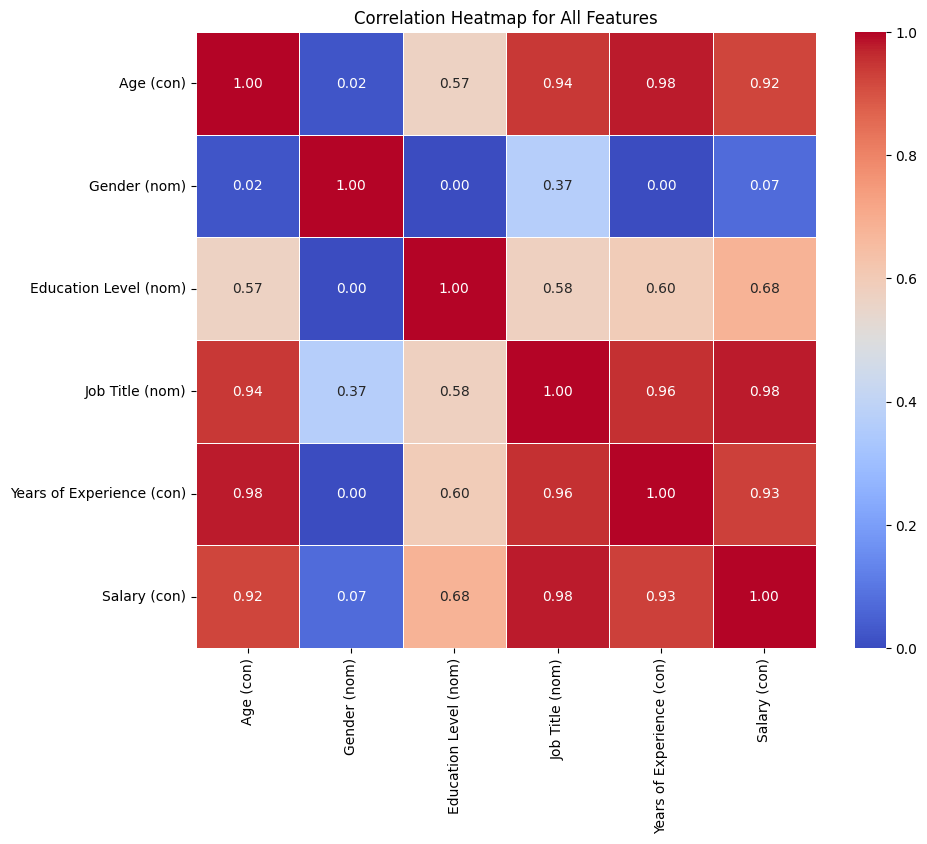

In [ ]:
# Calculate the association matrix
complete_corr = associations(filtered_data,
                             nominal_columns=identify_nominal_columns(filtered_data),
                             plot=False,
                             mark_columns=True,
                             )

# Extract the correlation matrix from the association matrix
corr_matrix = complete_corr['corr']

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for All Features')
plt.show()

## Feature Engineering

In [ ]:
def data_processor(df):
    """
    Alter data frame
    Input:
      + data
    Return:
      + Dataframe
    """
    title_mapping = {
      'Senior': ['Senior', 'Sr.', 'Lead'],
      'Director': ['Director', 'Managing Director', 'Executive Director','Chief', 'CEO', 'Executive'],
      'Junior': ['Junior','Jr.'],
      'Manager': ['Manager', 'Team Lead', 'Project Manager', 'VP'],
      'Associate': ['Associate', 'Assistant'],
      'Intern': ['Intern'],
      'Specialist': ['Specialist']
    }

    profession_mapping = {
      'Marketing': ['Marketing', 'Event', 'Social', 'Copywriter', 'Writer', 'Creative', 'Public', 'Content', 'Advertising'],
      'IT': ['IT', 'Information Technology', 'Software Engineer', 'Developer', 'UX', 'Designer', 'Software', 'Technical', 'Technology'],
      'Research': ['Market Research', 'Scientist', 'Data', 'Researcher', 'Research'],
      'Business': ['Business', 'Customer', 'Finance', 'Financial', 'Sales', 'Sale', 'Strategy', 'Consultant'],
      'Operation': ['Operation', 'Help Desk', 'Administrative', 'Product', 'Project', 'Supply Chain', 'Quality'],
      'HR': ['HR', 'Recruiter', 'Recruit', 'Human Resources', 'Training', 'Human'],
      'Engineer': ['Engineer', 'Engineering'],
      'Account': ['Account']
    }

    df['Title'] = ''
    df['Profession'] = ''

    for index, row in df.iterrows():
      found_title = False
      for title, keyword in title_mapping.items():
        for key in keyword:
          if row['Title'] != '':
            continue
          elif key in row['Job Title']:
            df.loc[index, 'Title'] = title
            found_title = True
            break

      if not found_title:
        df.loc[index, 'Title'] = 'Other'

      found_profession = False
      for profession, keyword in profession_mapping.items():
        for key in keyword:
          if row['Profession'] != '':
            continue
          elif key in row['Job Title']:
            df.loc[index, 'Profession'] = profession
            found_profession = True
            break

      if not found_profession:
          df.loc[index, 'Profession'] = 'Other'

    df = df.drop(columns=['Job Title'], axis=1)


    return df

In [ ]:
add = data_processor(filtered_data)

In [ ]:
cat_feats = add.select_dtypes(include='object').columns
num_feats = add.select_dtypes(exclude='object').columns
n_unique_df = {}
n_unique_df = {
    var:pd.DataFrame(add[var].value_counts())
    for var in add[cat_feats]
    }
multi_table([n_unique_df[col] for col in cat_feats])

,count
Gender,
Male,194
Female,179
,count
Education Level,
Bachelor's,224
Master's,98
PhD,51
,count
Title,


In [ ]:
def onehot_enc(df):
  df = pd.get_dummies(df, columns=cat_feats)
  return df

def numerical_enc(df):
  scaler = StandardScaler()
  df[num_feats] = scaler.fit_transform(df[num_feats])
  return df

In [ ]:
df_encoded = onehot_enc(add)
df_encoded = numerical_enc(df_encoded)

In [ ]:
class NN(pl.LightningModule):
  def __init__(self, input_channels, num_layers, kernel_size, lr=1e-3):
    super().__init__()
    self.save_hyperparameters()
    self.lr = lr
    self.input_shape = input_channels
    self.hidden_dims = hidden_dims
    self.kernel_size = kernel_size


    self.layers = nn.Sequential()
    self.layers.append(nn.Linear(self.input_channels, self.num_layers[0]))
    self.layers.append(nn.ReLU())
    self.layers.append(nn.Conv1d(self.num_layers[0], self.num_layers[1], self.kernel_size))
    self.layers.append(nn.BatchNorm1d(self.num_layers[1]))
    self.layers.append(nn.Dropout(0.1))
    self.layers.append(nn.Conv1d(self.num_layers[1], self.num_layers[2], self.kernel_size))
    self.layers.append(nn.MaxPool1d(self.num_layers[2]))
    self.layers.append(nn.Linear(self.num_layers[-1], 1))
    self.layers.append(nn.Softmax())

  def forward(self, X):
    X = X.unsqueeze(1)
    return self.layers(X)

  def configure_optimizers(self):
    return torch.optim.Adam(self.parameters(), lr=self.lr)


### A short report

Please tell us what you did and how did it work.

`<YOUR_TEXT_HERE>`, i guess...

## Recommended options

#### A) CNN architecture

All the tricks you know about dense and convolutional neural networks apply here as well.
* Dropout. Nuff said.
* Batch Norm. This time it's `nn.BatchNorm*`/`L.BatchNormalization`
* Parallel convolution layers. The idea is that you apply several nn.Conv1d to the same embeddings and concatenate output channels.
* More layers, more neurons, ya know...


#### B) Play with pooling

There's more than one way to perform pooling:
* Max over time (independently for each feature)
* Average over time (excluding PAD)
* Softmax-pooling:
$$ out_{i, t} = \sum_t {h_{i,t} \cdot {{e ^ {h_{i, t}}} \over \sum_\tau e ^ {h_{j, \tau}} } }$$

* Attentive pooling
$$ out_{i, t} = \sum_t {h_{i,t} \cdot Attn(h_t)}$$

, where $$ Attn(h_t) = {{e ^ {NN_{attn}(h_t)}} \over \sum_\tau e ^ {NN_{attn}(h_\tau)}}  $$
and $NN_{attn}$ is a dense layer.

The optimal score is usually achieved by concatenating several different poolings, including several attentive pooling with different $NN_{attn}$ (aka multi-headed attention).

The catch is that keras layers do not inlude those toys. You will have to [write your own keras layer](https://keras.io/layers/writing-your-own-keras-layers/). Or use pure tensorflow, it might even be easier :)

#### C) Fun with words

It's not always a good idea to train embeddings from scratch. Here's a few tricks:

* Use a pre-trained embeddings from `gensim.downloader.load`. See last lecture.
* Start with pre-trained embeddings, then fine-tune them with gradient descent. You may or may not download pre-trained embeddings from [here](http://nlp.stanford.edu/data/glove.6B.zip) and follow this [manual](https://keras.io/examples/nlp/pretrained_word_embeddings/) to initialize your Keras embedding layer with downloaded weights.
* Use the same embedding matrix in title and desc vectorizer


#### D) Going recurrent

We've already learned that recurrent networks can do cool stuff in sequence modelling. Turns out, they're not useless for classification as well. With some tricks of course..

* Like convolutional layers, LSTM should be pooled into a fixed-size vector with some of the poolings.
* Since you know all the text in advance, use bidirectional RNN
  * Run one LSTM from left to right
  * Run another in parallel from right to left
  * Concatenate their output sequences along unit axis (dim=-1)

* It might be good idea to mix convolutions and recurrent layers differently for title and description


#### E) Optimizing seriously

* You don't necessarily need 100 epochs. Use early stopping. If you've never done this before, take a look at [early stopping callback(keras)](https://keras.io/callbacks/#earlystopping) or in [pytorch(lightning)](https://pytorch-lightning.readthedocs.io/en/latest/common/early_stopping.html).
  * In short, train until you notice that validation
  * Maintain the best-on-validation snapshot via `model.save(file_name)`
  * Plotting learning curves is usually a good idea
  
Good luck! And may the force be with you!